# Explore here

In [121]:
import pandas as pd
from sklearn.model_selection import train_test_split
import plotly.express as px
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from pickle import dump

**Step 1. Reading the processed dataset**

In [122]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
total_data = pd.read_csv(url,sep=';')
total_data


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [123]:
print(max(total_data["quality"]))

8


In [124]:
def calidad(q):
    if q <= 3:
        return 0  
    elif q <= 6:
        return 1  
    else:
        return 2  

total_data['label'] = total_data['quality'].apply(calidad)
total_data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1


In [125]:
X = total_data.drop(["label", "quality"], axis=1)
Y = total_data["label"]
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)
X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
493,8.7,0.690,0.31,3.0,0.086,23.0,81.0,1.00020,3.48,0.74,11.6
354,6.1,0.210,0.40,1.4,0.066,40.5,165.0,0.99120,3.25,0.59,11.9
342,10.9,0.390,0.47,1.8,0.118,6.0,14.0,0.99820,3.30,0.75,9.8
834,8.8,0.685,0.26,1.6,0.088,16.0,23.0,0.99694,3.32,0.47,9.4
705,8.4,1.035,0.15,6.0,0.073,11.0,54.0,0.99900,3.37,0.49,9.9


In [126]:
target="label"
predictoras =[var for var in X.columns]
print(f"Predictoras: {predictoras}")
print(f"Target: {target}")

Predictoras: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Target: label


In [127]:
fig = px.scatter_3d(total_data,x="alcohol",y="pH", z="sulphates",color="label",size=total_data["alcohol"].abs(),
                    width=1000,height=500,color_continuous_scale="Viridis")
camera = dict( up=dict(x=1, y=3.5, z=0),eye=dict(x=2, y=0, z=0))
fig.update_layout(scene_camera=camera)
fig.show()

In [128]:
fig = px.scatter_3d(total_data,x="free sulfur dioxide",y="total sulfur dioxide", z="density",color="label",
                    size=total_data["free sulfur dioxide"].abs(),width=1000,height=500,color_continuous_scale="Viridis")
camera = dict( up=dict(x=1, y=3.5, z=0),eye=dict(x=2, y=0, z=0))
fig.update_layout(scene_camera=camera)
fig.show()

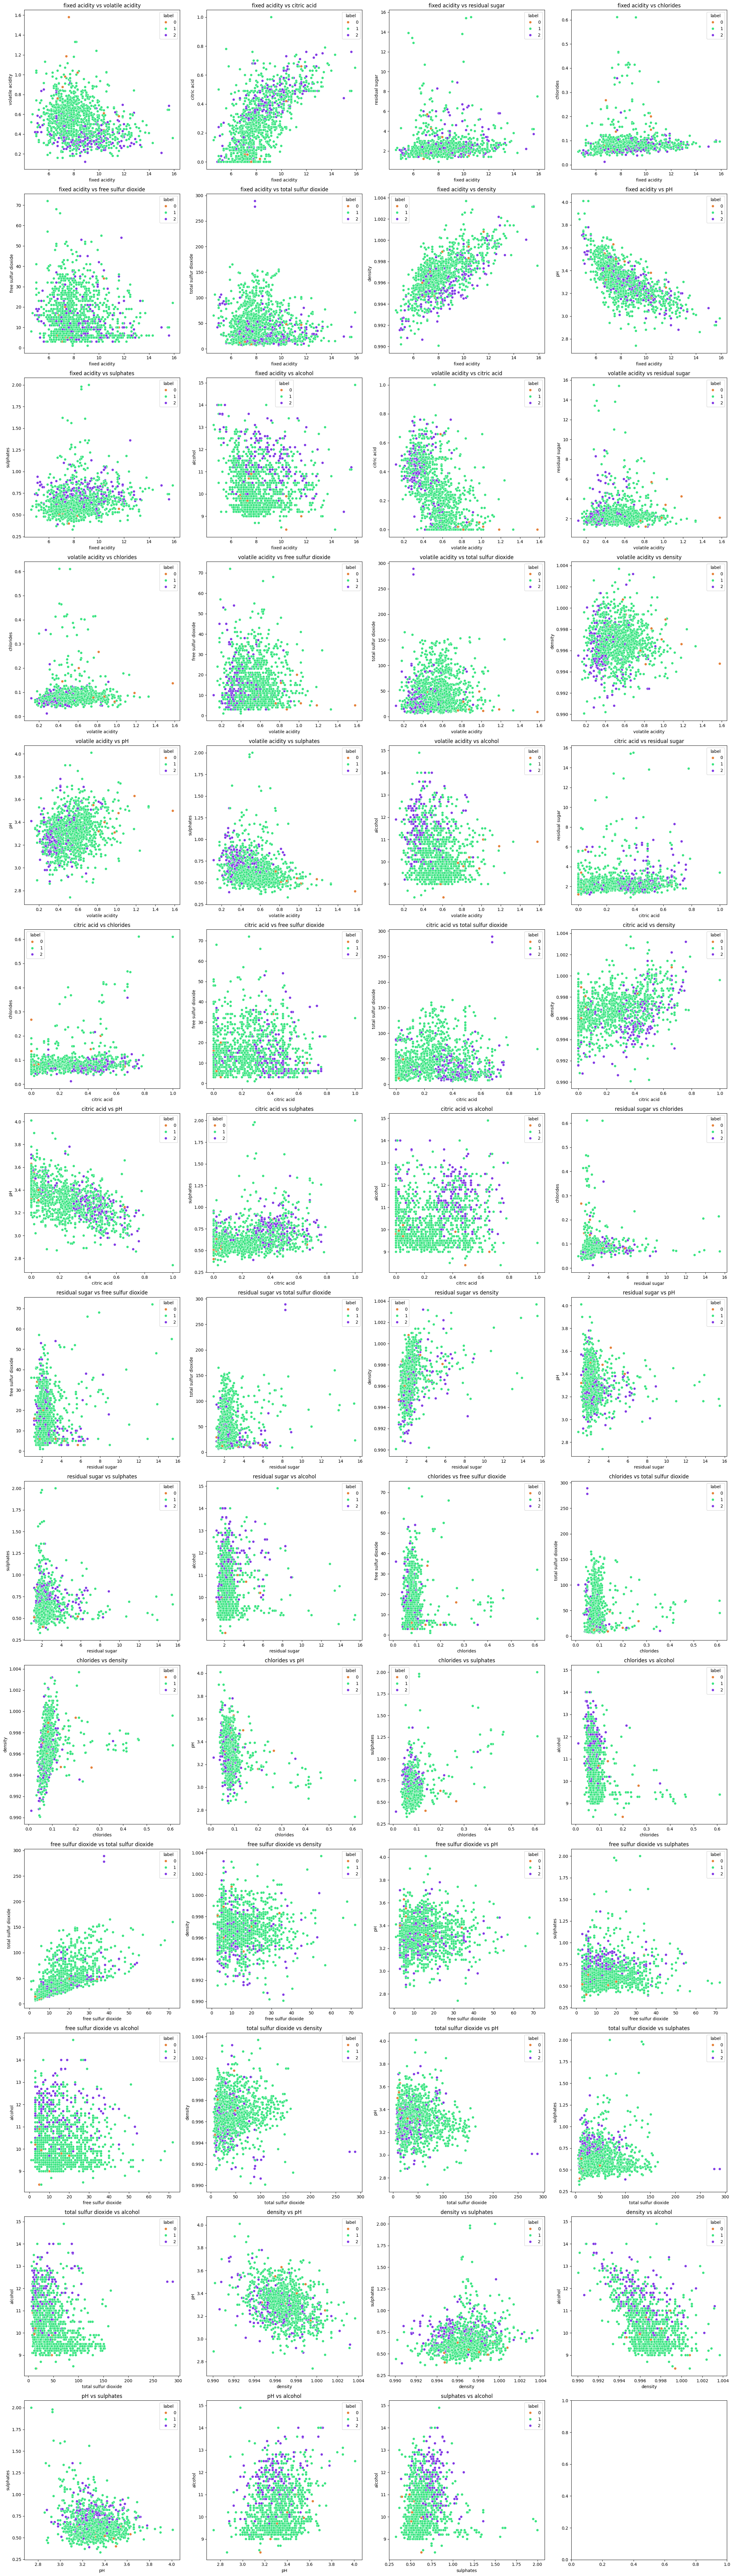

In [129]:
n_cols = 4
n_rows = math.ceil(len(combinaciones) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows))
palette = ["#E58139", "#39E581", "#8139E5"]
axes = axes.flatten()
for i, comb in enumerate(combinaciones):
    x_var=comb[0]
    y_var=comb[1]
    sns.scatterplot(ax=axes[i],data=total_data, x=x_var, y=y_var,hue=target,palette=palette)
    axes[i].set_title(f"{x_var} vs {y_var}")
plt.tight_layout()
plt.show()

**Step 2: Initialization and training of the model**

In [130]:
model = KNeighborsClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
ac1=accuracy_score(y_test, y_pred)
matriz=confusion_matrix(y_test, y_pred)
reporte=classification_report(y_test, y_pred)
print(f"La precisión es: {ac1}")
print(f"La matriz es: {matriz}")
print(f"El reporte es: {reporte}")


La precisión es: 0.853125
La matriz es: [[  0   1   0]
 [  0 263   9]
 [  0  37  10]]
El reporte es:               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.87      0.97      0.92       272
           2       0.53      0.21      0.30        47

    accuracy                           0.85       320
   macro avg       0.47      0.39      0.41       320
weighted avg       0.82      0.85      0.82       320



/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [131]:
dump(model, open("knn_classifier_default.sav", "wb"))

**Choose the best k**

In [132]:
accuracies = []

for k in range(1,21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_k_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_k_pred))
    print(f"Valor {k}: y su precisión es {accuracy_score(y_test, y_k_pred)}")
acc_opt=max(accuracies)
k_opt=accuracies.index(acc_opt)
print(f"El mejor k es {k_opt} y su precisión es {acc_opt}")

Valor 1: y su precisión es 0.846875
Valor 2: y su precisión es 0.84375
Valor 3: y su precisión es 0.84375
Valor 4: y su precisión es 0.853125
Valor 5: y su precisión es 0.853125
Valor 6: y su precisión es 0.840625
Valor 7: y su precisión es 0.8375
Valor 8: y su precisión es 0.840625
Valor 9: y su precisión es 0.834375
Valor 10: y su precisión es 0.83125
Valor 11: y su precisión es 0.846875
Valor 12: y su precisión es 0.840625
Valor 13: y su precisión es 0.834375
Valor 14: y su precisión es 0.84375
Valor 15: y su precisión es 0.846875
Valor 16: y su precisión es 0.840625
Valor 17: y su precisión es 0.84375
Valor 18: y su precisión es 0.846875
Valor 19: y su precisión es 0.846875
Valor 20: y su precisión es 0.85
El mejor k es 3 y su precisión es 0.853125


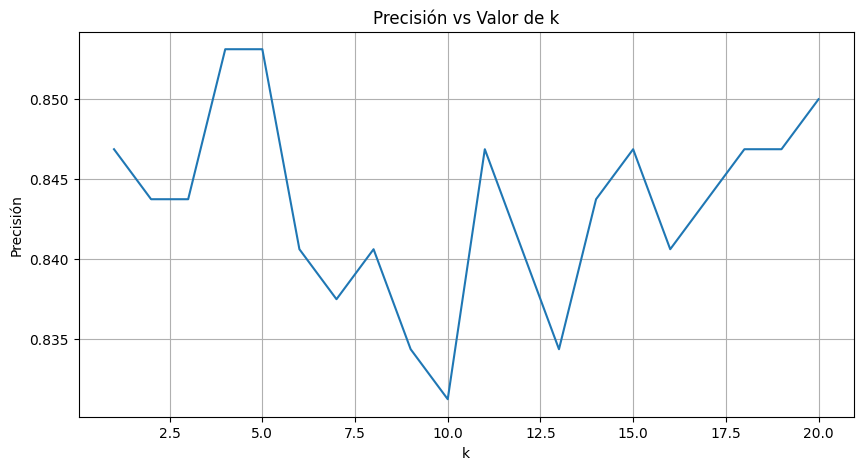

In [133]:
plt.figure(figsize=(10, 5))
plt.plot(range(1,21), accuracies)
plt.title("Precisión vs Valor de k")
plt.xlabel("k")
plt.ylabel("Precisión")
plt.grid(True)
plt.show()